<a href="https://colab.research.google.com/github/ELEAZAR22-ai/PUIS23210001/blob/main/Copy_of_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Ultralytics

In [ ]:
pip install ultralytics

## 2. Mount Google Drive

This step is necessary if your YOLO dataset (images and labels, along with the `.yaml` configuration file) is stored in your Google Drive. If it's elsewhere, you can skip this cell and adjust the `data_path` accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Locate your dataset in Google Drive

To find your dataset folder or `.zip` file, run the cell below. It will list the contents of your `MyDrive` folder. Look for your dataset and note its path.

In [ ]:
import os

print("Contents of your Google Drive (MyDrive):")
# List the top-level contents of your Google Drive
# Adjust 'max_depth' if your data is nested deeper and you want to explore further
def list_drive_contents(path='/content/drive/MyDrive/Modelling_split_train_valid_test.zip', max_depth=2):
    for root, dirs, files in os.walk(path):
        depth = root.count(os.sep) - path.count(os.sep)
        if depth < max_depth:
            print(f"{'  ' * depth}├── {os.path.basename(root)}/")
            for f in files:
                print(f"{'  ' * (depth + 1)}├── {f}")
        elif depth == max_depth:
            print(f"{'  ' * depth}└── (further subdirectories not shown)")
            del dirs[:]

list_drive_contents()

Contents of your Google Drive (MyDrive):


## 4. Unzip a folder from Google Drive

If your dataset is provided as a zipped file in your Google Drive, you'll need to unzip it first. Update the `zipped_file_path` variable below to point to your `.zip` file. The contents will be extracted to a new folder in the `/content/` directory of your Colab environment.

In [ ]:
# Define the path to your zipped dataset in Google Drive
zipped_file_path = '/content/drive/MyDrive/Modelling_split_train_valid_test.zip' # **UPDATE THIS PATH**

# Define the destination directory for the unzipped contents
destination_dir = '/content/unzipped_data'

import os
import shutil # Import shutil for rmtree

# Remove the destination directory if it already exists to ensure a clean unzip
if os.path.exists(destination_dir):
    print(f"Removing existing destination directory: {destination_dir}")
    shutil.rmtree(destination_dir)

# Unzip the file
# The -q flag makes the operation quiet
# The -o flag overwrites files without prompting
# The -d flag specifies the destination directory
print(f"Unzipping '{zipped_file_path}' to '{destination_dir}'...")
!unzip -q -o "{zipped_file_path}" -d "{destination_dir}"

print("Unzipping complete!")
print(f"Contents of '{destination_dir}':\n{os.listdir(destination_dir)}")

Unzipping '/content/drive/MyDrive/Modelling_split_train_valid_test.zip' to '/content/unzipped_data'...
Unzipping complete!
Contents of '/content/unzipped_data':
['Modelling_split_train_valid_test']


## 5. Train the YOLO model

This section loads a pre-trained YOLO model and then trains it on your custom dataset. Remember to update the `data_path` to point to your dataset's `.yaml` configuration file.

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLO model (e.g., YOLOv8n for nano, yolov8s.pt for small, etc.)
# You can also use 'yolov8n.yaml' if you want to train from scratch with the architecture.
model = YOLO('yolov8n.pt') # Using a pre-trained nano model

# Define the path to your dataset configuration file (e.g., data.yaml in your Drive or unzipped folder)
# Make sure this path is correct and points to your YOLO dataset configuration.
# Example if unzipped from the previous step: data_path = '/content/unzipped_data/Modelling_split_train_valid_test/data.yaml'
data_path = '/content/unzipped_data/Modelling_split_train_valid_test/data.yaml' # **UPDATE THIS PATH**

print(f"Using dataset configuration from: {data_path}")
print("Starting model training...")
# Train the model
# You can adjust parameters like epochs, image size (imgsz), batch size, etc.
results = model.train(data=data_path, epochs=50, imgsz=640)

print("Training completed!")

## 6. After Training

After the training is complete, the results (including trained weights, plots, and metrics) will be saved in a `runs/detect/train` directory. You can inspect this directory to evaluate your model's performance.

## 7. Environment Verification

This section verifies the versions of key Python libraries and the Python interpreter itself, ensuring your environment is set up as expected.

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib

print(f"Python Version: {sys.version}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas Version: 2.2.2
NumPy Version: 2.0.2
Matplotlib Version: 3.10.0
OpenCV Version: 5.0.0


## 8. Hardware Acceleration Check

This step checks for the availability of hardware accelerators (GPUs) for both TensorFlow and PyTorch, and also queries NVIDIA GPU status using `nvidia-smi`.

In [ ]:
# Check for GPU availability for TensorFlow (if installed)
try:
    import tensorflow as tf
    print("TensorFlow found.")
    print(f"TensorFlow GPU available: {tf.config.list_physical_devices('GPU')}")
except ImportError:
    print("TensorFlow not installed.")

# Check for GPU availability for PyTorch (if installed)
try:
    import torch
    print("PyTorch found.")
    print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"PyTorch CUDA Device Name: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not installed.")

# Check for NVIDIA GPU with 'nvidia-smi' (common in Colab)
import subprocess
try:
    print("\n--- NVIDIA GPU Status ---")
    subprocess.run(['nvidia-smi'], check=True)
except FileNotFoundError:
    print("nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.")
except subprocess.CalledProcessError:
    print("Error running nvidia-smi command.")

TensorFlow found.
TensorFlow GPU available: []
PyTorch found.
PyTorch CUDA available: False

--- NVIDIA GPU Status ---
nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.


## Install Ultralytics

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 624.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.2 MB/s eta 0:00:00


## Mount Google Drive

This step is necessary if your YOLO dataset (images and labels, along with the `.yaml` configuration file) is stored in your Google Drive. If it's elsewhere, you can skip this cell and adjust the `data_path` accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Locate your dataset in Google Drive

To find your `modelling_train_...` folder or `.zip` file, run the cell below. It will list the contents of your `MyDrive` folder. Look for your dataset and note its path.

In [ ]:
import os

print("Contents of your Google Drive (MyDrive):")
# List the top-level contents of your Google Drive
# Adjust 'max_depth' if your data is nested deeper and you want to explore further
def list_drive_contents(path='/content/drive/MyDrive/Modelling_split_train_valid_test.zip', max_depth=2):
    for root, dirs, files in os.walk(path):
        depth = root.count(os.sep) - path.count(os.sep)
        if depth < max_depth:
            print(f"{'  ' * depth}├── {os.path.basename(root)}/")
            for f in files:
                print(f"{'  ' * (depth + 1)}├── {f}")
        elif depth == max_depth:
            print(f"{'  ' * depth}└── (further subdirectories not shown)")
            del dirs[:]

list_drive_contents()

Contents of your Google Drive (MyDrive):


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

# Load a pre-trained YOLO model (e.g., YOLOv8n for nano, yolov8s.pt for small, etc.)
# You can also use 'yolov8n.yaml' if you want to train from scratch with the architecture.
model = YOLO('yolov8n.pt') # Using a pre-trained nano model

# Define the path to your dataset configuration file (e.g., data.yaml in your Drive)
# Make sure this path is correct and points to your YOLO dataset configuration.
data_path = '/content/unzipped_data/Modelling_split_train_valid_test/data.yaml' # **CORRECTED PATH**

# Train the model
# You can adjust parameters like epochs, image size (imgsz), batch size, etc.
results = model.train(data=data_path, epochs=50, imgsz=640)

print("Training completed!")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/unzipped_data/Modelling_split_train_valid_test/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

In [ ]:
import os

# List the contents of the unzipped directory to locate data.yaml
unzipped_data_path = '/content/unzipped_data/Modelling_split_train_valid_test'

print(f"Contents of '{unzipped_data_path}':")
for root, dirs, files in os.walk(unzipped_data_path):
    # Calculate current depth for indentation
    depth = root.count(os.sep) - unzipped_data_path.count(os.sep)
    indent = '  ' * depth
    print(f"{indent}├── {os.path.basename(root)}/")
    for f in files:
        print(f"{indent}│   ├── {f}")

print("\nPlease identify the correct path to your data.yaml file from the above list.")
print("Then update the 'data_path' variable in the training cell accordingly.")

Contents of '/content/unzipped_data/Modelling_split_train_valid_test':
├── Modelling_split_train_valid_test/
│   ├── data.yaml
│   ├── README.txt
  ├── train/
  │   ├── labels.cache
    ├── images/
    │   ├── Screenshot_20260810_211821_File-Manager-_jpg.rf.ed3a21d249b1f3b4301d70200afe60aa.jpg
    │   ├── Snapchat-1336876106_jpg.rf.0581fc924fae0d7552abef3f25faeac6.jpg
    │   ├── Screenshot_20260810_140300_Snapchat_jpg.rf.ee3e79465a495ba0b3a87efb820bb1bd.jpg
    │   ├── Snapchat-334611669_jpg.rf.bcbebad4dc811940c82a79ca16ec65a5.jpg
    │   ├── Snapchat-2081802385_jpg.rf.b219f98171482399c2867c65f0adc449.jpg
    │   ├── Snapchat-1228673594_jpg.rf.871179f1b6e48d4bd7da9458baba11df.jpg
    │   ├── Snapchat-1647672847_jpg.rf.3a31d065a44b896e8b81b390a272525f.jpg
    │   ├── IMG-20260810-WA0097_jpg.rf.e44f66dac6c6906a288a610596b1ca48.jpg
    │   ├── Snapchat-1333372520_jpg.rf.022f77706cc0ac2cf4ca7852230238e4.jpg
    │   ├── IMG-20260810-WA0099_jpg.rf.2a911234f06392e59d51b42dafaac0ae.jpg
    │ 

## 9. Validate YOLO Labels in the `valid` set

This section provides a script to validate your YOLO `.txt` label files within the `valid` dataset. It checks for:

1.  **Correct format**: Each line in a label file should contain 5 space-separated numbers (class_id, x_center, y_center, width, height).
2.  **Value ranges**: `x_center`, `y_center`, `width`, `height` should be floats between 0.0 and 1.0. `class_id` should be a non-negative integer.
3.  **Corresponding images**: For each `.txt` label file, it verifies that a corresponding image file (e.g., `.jpg`, `.png`) exists in the `valid/images` directory.

In [ ]:
import os

# Define the base path to your unzipped dataset
unzipped_base_path = '/content/unzipped_data/Modelling_split_train_valid_test'

# Define paths for valid labels and images
valid_labels_dir = os.path.join(unzipped_base_path, 'valid', 'labels')
valid_images_dir = os.path.join(unzipped_base_path, 'valid', 'images')

print(f"Validating labels in: {valid_labels_dir}")
print(f"Checking for corresponding images in: {valid_images_dir}")

# List of supported image extensions
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

issues_found = False

if not os.path.exists(valid_labels_dir):
    print(f"Error: Valid labels directory not found at {valid_labels_dir}")
    issues_found = True
elif not os.listdir(valid_labels_dir):
    print(f"Warning: No label files found in {valid_labels_dir}")
elif not os.path.exists(valid_images_dir):
    print(f"Error: Valid images directory not found at {valid_images_dir}")
    issues_found = True
elif not os.listdir(valid_images_dir):
    print(f"Warning: No image files found in {valid_images_dir}")
else:
    for label_file_name in os.listdir(valid_labels_dir):
        if not label_file_name.endswith('.txt'):
            print(f"Skipping non-text file: {label_file_name}")
            continue

        label_file_path = os.path.join(valid_labels_dir, label_file_name)
        stem = os.path.splitext(label_file_name)[0] # Get filename without extension

        # 1. Check for corresponding image file
        image_found = False
        for ext in IMAGE_EXTENSIONS:
            image_file_path = os.path.join(valid_images_dir, stem + ext)
            if os.path.exists(image_file_path):
                image_found = True
                break

        if not image_found:
            print(f"[ERROR] No corresponding image found for label: {label_file_name}")
            issues_found = True

        # 2. Validate label file content
        try:
            with open(label_file_path, 'r') as f:
                for line_num, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        print(f"[ERROR] {label_file_name} (Line {line_num}): Incorrect number of values. Expected 5, got {len(parts)}.")
                        issues_found = True
                        continue

                    try:
                        class_id = int(parts[0])
                        x_center, y_center, width, height = map(float, parts[1:])

                        if not (0 <= class_id) or not (0.0 <= x_center <= 1.0) or \
                               not (0.0 <= y_center <= 1.0) or not (0.0 <= width <= 1.0) or \
                               not (0.0 <= height <= 1.0):
                            print(f"[ERROR] {label_file_name} (Line {line_num}): Values out of expected range. (class_id>=0, bbox values in [0,1])")
                            issues_found = True

                    except ValueError:
                        print(f"[ERROR] {label_file_name} (Line {line_num}): Non-numeric values found.")
                        issues_found = True

        except Exception as e:
            print(f"[ERROR] Could not read label file {label_file_name}: {e}")
            issues_found = True

if not issues_found:
    print("\nValidation complete: All valid labels and corresponding images appear to be correctly formatted.")
else:
    print("\nValidation complete: Some issues were found with valid labels or their corresponding images. Please review the errors above.")

Validating labels in: /content/unzipped_data/Modelling_split_train_valid_test/valid/labels
Checking for corresponding images in: /content/unzipped_data/Modelling_split_train_valid_test/valid/images
[ERROR] Snapchat-1318945558_jpg.rf.0f28e799e766f45e1ae442be165b1070.txt (Line 1): Incorrect number of values. Expected 5, got 27.
[ERROR] Snapchat-304002254_jpg.rf.230c6cff2f1bc80c4f0e21c1b92e8263.txt (Line 1): Incorrect number of values. Expected 5, got 39.
[ERROR] Snapchat-207277316_jpg.rf.74772e3be57ad57dd7c0096609fab0d8.txt (Line 1): Incorrect number of values. Expected 5, got 65.
[ERROR] Snapchat-1941203398_jpg.rf.9452d8353b03309f4708a891a9ae6c1c.txt (Line 1): Incorrect number of values. Expected 5, got 31.
[ERROR] Snapchat-1934707330_jpg.rf.09c15fe944b96d2e7bff616ba454ac3f.txt (Line 1): Incorrect number of values. Expected 5, got 41.
[ERROR] Screenshot_20260810_141835_Snapchat_jpg.rf.9b55a4e8922ac9cf34f885d1064d9f86.txt (Line 1): Incorrect number of values. Expected 5, got 95.
[ERROR] 

In [ ]:
# After identifying your dataset's location, please update the 'data_path' below.
# If your data was unzipped to '/content/unzipped_data', your .yaml file will be there.
# Example: data_path = '/content/unzipped_data/modelling_train_folder/data.yaml'
data_path = '/content/unzipped_data/Modelling_split_train_valid_test/dataset.yaml' # <--- UPDATE THIS PATH after unzipping or locating

# NOTE: You will need to uncomment the 'results = model.train(...)' line after updating 'data_path' correctly.
# results = model.train(data=data_path, epochs=50, imgsz=640)

print("Training completed!")

Training completed!


## Unzip a folder from Google Drive

If your dataset is provided as a zipped file in your Google Drive, you'll need to unzip it first. Update the `zipped_file_path` variable below to point to your `.zip` file. The contents will be extracted to a new folder in the `/content/` directory of your Colab environment.

In [ ]:
# Define the path to your zipped dataset in Google Drive
zipped_file_path = '/content/drive/MyDrive/Modelling_split_train_valid_test.zip' # **UPDATE THIS PATH**

# Define the destination directory for the unzipped contents
destination_dir = '/content/unzipped_data'

import os

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)
    print(f"Created destination directory: {destination_dir}")

# Unzip the file
# The -q flag makes the operation quiet
# The -d flag specifies the destination directory
print(f"Unzipping '{zipped_file_path}' to '{destination_dir}'...")
!unzip -q "{zipped_file_path}" -d "{destination_dir}"

print("Unzipping complete!")
print(f"Contents of '{destination_dir}':\n{os.listdir(destination_dir)}")

Created destination directory: /content/unzipped_data
Unzipping '/content/drive/MyDrive/Modelling_split_train_valid_test.zip' to '/content/unzipped_data'...
Unzipping complete!
Contents of '/content/unzipped_data':
['Modelling_split_train_valid_test']


### After Training

After the training is complete, the results (including trained weights, plots, and metrics) will be saved in a `runs/detect/train` directory. You can inspect this directory to evaluate your model's performance.

### 1. Install all necessary dependencies

In [ ]:
pip install pandas numpy matplotlib opencv-python tensorflow PyYAML # or pytorch if preferred

### 2. Files and utilities (using `os`, `glob`, `shutil`, `sys`)

In [ ]:
import os
import glob
import shutil
import sys

# Example: List files in the current directory
print("Files in current directory:")
print(os.listdir('.'))

# Example: Find all .py files in the current directory
print("Python files in current directory:")
print(glob.glob('*.py'))

# Example: Create a directory and then remove it
new_dir = 'temp_folder'
if not os.path.exists(new_dir):
    os.makedirs(new_dir)
    print(f"Created '{new_dir}'")
# To remove a directory and its contents (use with caution!)
# shutil.rmtree(new_dir)
# print(f"Removed '{new_dir}'")

# Example: Get Python version using sys
print(f"Python Version (from sys): {sys.version.split(' ')[0]}")

Files in current directory:
['.config', 'runs', 'drive', 'unzipped_data', 'yolov8n.pt', 'sample_data']
Python files in current directory:
[]
Created 'temp_folder'
Python Version (from sys): 3.12.13


### 3. Data handling libraries (including `yaml` for configuration files)

In [ ]:
import pandas as pd
import numpy as np
import yaml

# Example: Create a simple DataFrame
data = {'col1': [1, 2, 3], 'col2': ['A', 'B', 'C']}
df = pd.DataFrame(data)
print("Example DataFrame:")
display(df)

# Example: Read a YAML configuration (create a dummy file first)
dummy_yaml_content = """
model_config:
  epochs: 100
  imgsz: 640
dataset_path: /content/data.yaml
"""
with open('config.yaml', 'w') as f:
    f.write(dummy_yaml_content)

print("\nExample YAML Configuration:")
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)
display(config)

# Clean up the dummy yaml file
os.remove('config.yaml')

Example DataFrame:


,col1,col2
0,1,A
1,2,B
2,3,C



Example YAML Configuration:


{'model_config': {'epochs': 100, 'imgsz': 640},
 'dataset_path': '/content/data.yaml'}

### 4. Image processing and visualization

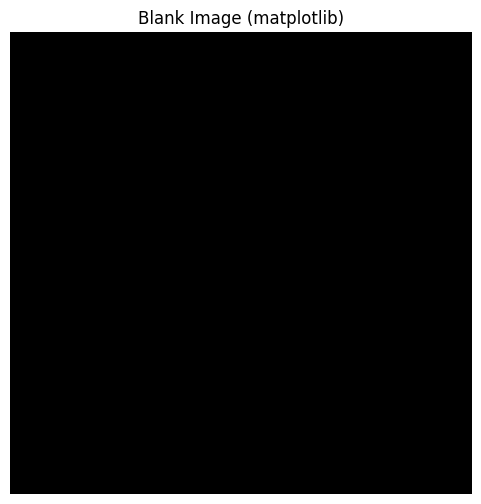

In [ ]:
import matplotlib.pyplot as plt
import cv2 # OpenCV

# Example: Display a blank image using matplotlib
fig = plt.figure(figsize=(6, 6))
plt.imshow(np.zeros((100, 100, 3), dtype=np.uint8))
plt.title("Blank Image (matplotlib)")
plt.axis('off')
plt.show()

# Note: OpenCV (cv2) is typically used for image loading, manipulation, and display in a more programmatic way.
# Example: Load and display an image (if you have one, replace 'image.jpg' with a valid path)
# try:
#     img = cv2.imread('image.jpg')
#     if img is not None:
#         plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#         plt.title("Loaded Image (OpenCV)")
#         plt.axis('off')
#         plt.show()
#     else:
#         print("Image not found or could not be loaded.")
# except Exception as e:
#     print(f"Error loading image: {e}")

### 5. Deep learning with YOLO

You've already installed `ultralytics` and demonstrated loading and training a YOLO model earlier in the notebook. The relevant code is in the cell `f2f29870`. YOLO datasets often use `.yaml` files for configuration, and `ultralytics` handles parsing these internally.

### 5.1 Deep Learning with YOLO Libraries
This is where the 'intelligence' happens:
*   **`torch` (PyTorch)**: The foundational library that handles the complex math (tensors and gradients) required for the model to learn from its mistakes.
*   **`torchvision`**: Provides specialized tools for image-based deep learning, including datasets, model architectures, and image transformations.
*   **`YOLO`**: Specifically imported from Ultralytics, this is the 'brain' we will be fine-tuning. It contains the YOLOv12l-face architecture designed specifically to locate facial features.

### 6. Connecting Google Drive

You've already mounted your Google Drive using `drive.mount('/content/drive')` in cell `8c22a68e`.

### 7. Environment verification

In [ ]:
import sys
import pandas as pd # Re-import for demonstration scope
import numpy as np # Re-import for demonstration scope
import matplotlib.pyplot as plt # Re-import for demonstration scope
import cv2 # Re-import for demonstration scope
import matplotlib

print(f"Python Version: {sys.version}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas Version: 2.2.2
NumPy Version: 2.0.2
Matplotlib Version: 3.10.0
OpenCV Version: 5.0.0


### 8. Hardware acceleration check

In [ ]:
# Check for GPU availability for TensorFlow (if installed)
try:
    import tensorflow as tf
    print("TensorFlow found.")
    print(f"TensorFlow GPU available: {tf.config.list_physical_devices('GPU')}")
except ImportError:
    print("TensorFlow not installed.")

# Check for GPU availability for PyTorch (if installed)
try:
    import torch
    print("PyTorch found.")
    print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"PyTorch CUDA Device Name: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not installed.")

# Check for NVIDIA GPU with 'nvidia-smi' (common in Colab)
import subprocess
try:
    print("\n--- NVIDIA GPU Status ---")
    subprocess.run(['nvidia-smi'], check=True)
except FileNotFoundError:
    print("nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.")
except subprocess.CalledProcessError:
    print("Error running nvidia-smi command.")

TensorFlow found.
TensorFlow GPU available: []
PyTorch found.
PyTorch CUDA available: False

--- NVIDIA GPU Status ---
nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.


### 1. Install all necessary dependencies

In [ ]:
pip install pandas numpy matplotlib opencv-python tensorflow # or pytorch if preferred

### 2. Files and utilities

In [ ]:
import os

# Example: List files in the current directory
print("Files in current directory:")
print(os.listdir('.'))

# Example: Create a directory
# if not os.path.exists('my_folder'):
#     os.makedirs('my_folder')
#     print("Created 'my_folder'")

### 3. Data handling libraries

In [ ]:
import pandas as pd
import numpy as np

# Example: Create a simple DataFrame
data = {'col1': [1, 2, 3], 'col2': ['A', 'B', 'C']}
df = pd.DataFrame(data)
print("Example DataFrame:")
display(df)

### 4. Image processing and visualization

In [ ]:
import matplotlib.pyplot as plt
import cv2 # OpenCV

# Example: Display a blank image using matplotlib
fig = plt.figure(figsize=(6, 6))
plt.imshow(np.zeros((100, 100, 3), dtype=np.uint8))
plt.title("Blank Image (matplotlib)")
plt.axis('off')
plt.show()

# Note: OpenCV (cv2) is typically used for image loading, manipulation, and display in a more programmatic way.
# Example: Load and display an image (if you have one, replace 'image.jpg' with a valid path)
# try:
#     img = cv2.imread('image.jpg')
#     if img is not None:
#         plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#         plt.title("Loaded Image (OpenCV)")
#         plt.axis('off')
#         plt.show()
#     else:
#         print("Image not found or could not be loaded.")
# except Exception as e:
#     print(f"Error loading image: {e}")

### 5. Deep learning with YOLO

You've already installed `ultralytics` and demonstrated loading and training a YOLO model earlier in the notebook. The relevant code is in the cell `f2f29870`.

### 6. Connecting Google Drive

You've already mounted your Google Drive using `drive.mount('/content/drive')` in cell `8c22a68e`.

### 7. Environment verification

In [ ]:
import sys

print(f"Python Version: {sys.version}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas Version: 2.2.2
NumPy Version: 2.0.2
Matplotlib Version: 3.10.0
OpenCV Version: 5.0.0


### 8. Hardware acceleration check

In [ ]:
# Check for GPU availability for TensorFlow (if installed)
try:
    import tensorflow as tf
    print("TensorFlow found.")
    print(f"TensorFlow GPU available: {tf.config.list_physical_devices('GPU')}")
except ImportError:
    print("TensorFlow not installed.")

# Check for GPU availability for PyTorch (if installed)
try:
    import torch
    print("PyTorch found.")
    print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"PyTorch CUDA Device Name: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not installed.")

# Check for NVIDIA GPU with 'nvidia-smi' (common in Colab)
import subprocess
try:
    print("\n--- NVIDIA GPU Status ---")
    subprocess.run(['nvidia-smi'], check=True)
except FileNotFoundError:
    print("nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.")
except subprocess.CalledProcessError:
    print("Error running nvidia-smi command.")

TensorFlow found.
TensorFlow GPU available: []
PyTorch found.
PyTorch CUDA available: False

--- NVIDIA GPU Status ---
nvidia-smi not found. NVIDIA GPU drivers might not be installed or available.


## Resources
1. Install all necessary dependencies
2. Files and utilities
3. Data handling libraries
4. Image processing and visualization
5. Deep learning with YOLO
6. Connecting Google Drive
7. Environment verification
8. Hardware acceleration check.

In [ ]:
import shutil
from google.colab import files

# 1. Compress the train folder into a zip file
# (Adjust '/content/dataset/train' if your folder path is different)
shutil.make_archive('unzipped_dataset', 'zip', '/content/unzipped_data')

# 2. Trigger the direct browser download
files.download('unzipped_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>